# Highway Intersection Multi-Agent Path Finding

This notebook extends the basic MAPF solver to handle a specific problem:

**Problem Description:**
- Grid of single-lane highways between four-way intersections (with variable edge lengths)
- Each agent has a list of target intersections to visit in sequence
- At each target, the agent becomes invisible for a specified number of timesteps (performing an action)
- Agents initialize at intersections near their first target (initialization takes time)
- After completing all targets, agents are removed at intersections near their last target (removal takes time)
- Target order may be predefined or flexible (optimizable)

**Solution Approach:**
- Break each agent's journey into segments (waypoints: init → target₁ → target₂ → ... → removal)
- For each segment, use CBS (Conflict-Based Search) to solve multi-agent pathfinding for ALL agents simultaneously
- This ensures true collision-free coordination between agents
- Insert "pause" periods at waypoints for actions, initialization, and removal
- Support both fixed and optimizable target orderings

## Setup and Imports

In [11]:
import sys
import os
import numpy as np
from itertools import permutations
from typing import List, Tuple, Dict, Optional

# Add the MAPF code directory to the Python path
mapf_path = os.path.abspath('../extern/mapf/code')
if mapf_path not in sys.path:
    sys.path.insert(0, mapf_path)

# Import MAPF modules
from cbs_basic import CBSSolver
from icbs_complete import ICBS_Solver
from visualize import Animation
from single_agent_planner import get_sum_of_cost

print("✓ Modules loaded successfully!")

✓ Modules loaded successfully!


## Helper Functions

In [12]:
def create_highway_grid(size: int, edge_length: int = 1) -> np.ndarray:
    """
    Create a highway grid where intersections are separated by highways.
    
    Args:
        size: Number of intersections per side
        edge_length: Length of highway segments between intersections (default 1)
                     Total grid will be size*(edge_length+1)+1 x size*(edge_length+1)+1
    
    Returns:
        2D array where True = obstacle, False = free space
    """
    if edge_length < 1:
        raise ValueError("edge_length must be at least 1")
    
    # Calculate grid size based on intersections and edge lengths
    # Formula: size intersections with (size-1) edges between them, plus borders
    spacing = edge_length + 1  # Distance between intersection centers
    grid_size = size * spacing + 1
    
    # Start with all obstacles
    grid = np.ones((grid_size, grid_size), dtype=bool)
    
    # Mark intersections as free (at positions 0, spacing, 2*spacing, ...)
    for i in range(0, grid_size, spacing):
        for j in range(0, grid_size, spacing):
            grid[i, j] = False
    
    # Mark horizontal highway segments (connecting intersections horizontally)
    for i in range(0, grid_size, spacing):
        for j in range(grid_size):
            grid[i, j] = False
    
    # Mark vertical highway segments (connecting intersections vertically)
    for i in range(grid_size):
        for j in range(0, grid_size, spacing):
            grid[i, j] = False
    
    return grid


def get_intersections(size: int, edge_length: int = 1) -> List[Tuple[int, int]]:
    """
    Get list of all intersection coordinates for a highway grid.
    
    Args:
        size: Number of intersections per side
        edge_length: Length of highway segments between intersections
    
    Returns:
        List of (row, col) tuples representing intersections
    """
    spacing = edge_length + 1
    grid_size = size * spacing + 1
    intersections = []
    for i in range(0, grid_size, spacing):
        for j in range(0, grid_size, spacing):
            intersections.append((i, j))
    return intersections


def find_nearest_intersection(pos: Tuple[int, int], intersections: List[Tuple[int, int]]) -> Tuple[int, int]:
    """
    Find the nearest intersection to a given position.
    
    Args:
        pos: (row, col) position
        intersections: List of intersection coordinates
    
    Returns:
        Nearest intersection coordinates
    """
    min_dist = float('inf')
    nearest = intersections[0]
    for intersection in intersections:
        dist = abs(pos[0] - intersection[0]) + abs(pos[1] - intersection[1])
        if dist < min_dist:
            min_dist = dist
            nearest = intersection
    return nearest


def extend_path_stationary(path: List[Tuple[int, int]], duration: int) -> List[Tuple[int, int]]:
    """
    Extend a path by keeping the agent stationary at the final position.
    
    Args:
        path: Original path
        duration: Number of timesteps to remain stationary
    
    Returns:
        Extended path
    """
    if not path:
        return path
    return path + [path[-1]] * duration


print("✓ Helper functions defined")

✓ Helper functions defined


## Multi-Target MAPF Solver

In [13]:
class HighwayIntersectionMAPF:
    """
    Solver for multi-agent pathfinding on highway grids with multiple targets per agent.
    """
    
    def __init__(self, 
                 grid: np.ndarray,
                 intersections: List[Tuple[int, int]],
                 init_time: int = 10,
                 action_time: int = 5,
                 removal_time: int = 10):
        """
        Initialize the highway intersection MAPF solver.
        
        Args:
            grid: 2D boolean array (True = obstacle)
            intersections: List of valid intersection coordinates
            init_time: Timesteps for agent initialization
            action_time: Timesteps for action at each target
            removal_time: Timesteps for agent removal
        """
        self.grid = grid
        self.intersections = intersections
        self.init_time = init_time
        self.action_time = action_time
        self.removal_time = removal_time
        
        # Convert grid to list format for MAPF solver
        self.map_list = [[bool(cell) for cell in row] for row in grid]
    
    def optimize_target_order(self, 
                              start: Tuple[int, int], 
                              targets: List[Tuple[int, int]]) -> List[Tuple[int, int]]:
        """
        Find the optimal order to visit targets (greedy nearest-neighbor).
        
        Args:
            start: Starting intersection
            targets: List of target intersections
        
        Returns:
            Optimized order of targets
        """
        if len(targets) <= 1:
            return targets
        
        # Greedy nearest-neighbor heuristic
        remaining = list(targets)
        ordered = []
        current = start
        
        while remaining:
            # Find nearest target
            nearest = min(remaining, 
                         key=lambda t: abs(t[0] - current[0]) + abs(t[1] - current[1]))
            ordered.append(nearest)
            remaining.remove(nearest)
            current = nearest
        
        return ordered
    
    def solve_single_agent(self,
                          targets: List[Tuple[int, int]],
                          optimize_order: bool = False) -> Tuple[List[Tuple[int, int]], List[Tuple[int, int]]]:
        """
        Solve path for a single agent with multiple targets.
        
        Args:
            targets: List of target intersections to visit
            optimize_order: Whether to optimize the order of targets
        
        Returns:
            Tuple of (full_path, actual_target_order)
        """
        if not targets:
            return [], []
        
        # Find initialization location (near first target)
        first_target = targets[0]
        init_location = find_nearest_intersection(first_target, self.intersections)
        
        # Optimize target order if requested
        if optimize_order:
            ordered_targets = self.optimize_target_order(init_location, targets)
        else:
            ordered_targets = targets
        
        # Build complete path
        full_path = []
        current_pos = init_location
        
        # Initialization period (stationary)
        full_path.extend([init_location] * self.init_time)
        
        # Visit each target
        for target in ordered_targets:
            # Solve single-agent path to this target
            solver = ICBS_Solver(self.map_list, [current_pos], [target])
            solution = solver.find_solution(disjoint=True)
            
            if solution is None or solution[0] is None:
                raise RuntimeError(f"No path found from {current_pos} to {target}")
            
            path_segment = solution[0][0]  # Get first (only) agent's path
            
            # Add path segment (excluding first position which is duplicate)
            full_path.extend(path_segment[1:])
            
            # Add action time at target (stationary)
            full_path.extend([target] * self.action_time)
            
            current_pos = target
        
        # Find removal location (near last target)
        last_target = ordered_targets[-1]
        removal_location = find_nearest_intersection(last_target, self.intersections)
        
        # Move to removal location if different from last target
        if removal_location != last_target:
            solver = ICBS_Solver(self.map_list, [current_pos], [removal_location])
            solution = solver.find_solution(disjoint=True)
            
            if solution is not None and solution[0] is not None:
                path_segment = solution[0][0]
                full_path.extend(path_segment[1:])
                current_pos = removal_location
        
        # Removal period (stationary)
        full_path.extend([current_pos] * self.removal_time)
        
        return full_path, ordered_targets
    
    def solve_multi_agent(self,
                         agent_targets: List[List[Tuple[int, int]]],
                         optimize_orders: List[bool]) -> Dict:
        """
        Solve paths for multiple agents with target sequences using proper multi-agent CBS.
        
        The problem is broken into segments where each segment moves all agents
        from their current target to their next target. CBS coordinates all agents
        in each segment to avoid collisions.
        
        Args:
            agent_targets: List of target lists (one per agent)
            optimize_orders: Whether to optimize order for each agent
        
        Returns:
            Dictionary with paths and metadata
        """
        num_agents = len(agent_targets)
        
        # Step 1: Determine starting positions and optimize target orders
        ordered_targets = []
        init_positions = []
        
        for i, (targets, optimize) in enumerate(zip(agent_targets, optimize_orders)):
            if not targets:
                raise ValueError(f"Agent {i} has no targets")
            
            # Find initialization location near first target
            init_pos = find_nearest_intersection(targets[0], self.intersections)
            init_positions.append(init_pos)
            
            # Optimize target order if requested
            if optimize:
                ordered = self.optimize_target_order(init_pos, targets)
            else:
                ordered = targets
            ordered_targets.append(ordered)
            
            print(f"Agent {i}: {len(ordered)} targets, starting at {init_pos}")
        
        # Step 2: Build waypoint sequences (init -> targets -> removal)
        all_waypoints = []
        for i, targets in enumerate(ordered_targets):
            waypoints = [init_positions[i]] + targets
            
            # Add removal location if different from last target
            removal_pos = find_nearest_intersection(targets[-1], self.intersections)
            if removal_pos != targets[-1]:
                waypoints.append(removal_pos)
            
            all_waypoints.append(waypoints)
        
        # Step 3: Solve each segment with multi-agent CBS
        complete_paths = [[pos] * self.init_time for pos in init_positions]
        max_segments = max(len(wp) - 1 for wp in all_waypoints)
        
        print(f"\nSolving {max_segments} segments with multi-agent CBS...")
        
        for segment in range(max_segments):
            print(f"  Segment {segment + 1}/{max_segments}...", end=" ")
            
            # Determine start and goal for each agent in this segment
            starts = []
            goals = []
            active_agents = []  # Track which agents are moving
            
            for agent_id, waypoints in enumerate(all_waypoints):
                if segment < len(waypoints) - 1:
                    # Agent has a next waypoint
                    starts.append(waypoints[segment])
                    goals.append(waypoints[segment + 1])
                    active_agents.append(agent_id)
                else:
                    # Agent finished, stays at last position
                    starts.append(waypoints[-1])
                    goals.append(waypoints[-1])
            
            # Solve multi-agent pathfinding for this segment
            cbs_solver = ICBS_Solver(self.map_list, starts, goals)
            solution = cbs_solver.find_solution(disjoint=True)
            
            if solution is None or solution[0] is None:
                print(f"WARNING: No solution found!")
                # Fall back: keep agents stationary
                for agent_id in range(num_agents):
                    complete_paths[agent_id].extend([starts[agent_id]] * 10)
            else:
                segment_paths = solution[0]
                nodes_gen, nodes_exp = solution[1], solution[2]
                print(f"✓ (cost: {get_sum_of_cost(segment_paths)}, nodes: {nodes_gen})")
                
                # Add segment paths (excluding first position which is duplicate)
                for agent_id, path in enumerate(segment_paths):
                    complete_paths[agent_id].extend(path[1:])
                
                # Add pause time at waypoints
                for agent_id, waypoints in enumerate(all_waypoints):
                    if segment < len(waypoints) - 2:
                        # At intermediate waypoint - action time
                        complete_paths[agent_id].extend([goals[agent_id]] * self.action_time)
                    elif segment == len(waypoints) - 2:
                        # At final waypoint - removal time
                        complete_paths[agent_id].extend([goals[agent_id]] * self.removal_time)
        
        # Pad paths to equal length
        max_length = max(len(p) for p in complete_paths)
        padded_paths = [extend_path_stationary(p, max_length - len(p)) for p in complete_paths]
        
        return {
            'paths': padded_paths,
            'ordered_targets': ordered_targets,
            'original_targets': agent_targets,
            'total_cost': get_sum_of_cost(padded_paths)
        }


print("✓ HighwayIntersectionMAPF class defined")

✓ HighwayIntersectionMAPF class defined


## Create Example Highway Grid

In [14]:
# Create a highway grid with variable edge length
intersection_count = 4
edge_length = 5  # Length of highway segments between intersections (try 1, 2, 3, etc.)

highway_grid = create_highway_grid(intersection_count, edge_length)
intersections = get_intersections(intersection_count, edge_length)

print(f"Grid parameters:")
print(f"  Intersections per side: {intersection_count}")
print(f"  Edge length (highway segment length): {edge_length}")
print(f"  Grid size: {highway_grid.shape}")
print(f"  Number of intersections: {len(intersections)}")
print(f"\nIntersections: {intersections[:10]}...")  # Show first 10

# Visualize the grid
print("\nGrid visualization (. = free, @ = obstacle):")
for row in highway_grid:
    print(''.join(['@' if cell else '.' for cell in row]))

Grid parameters:
  Intersections per side: 4
  Edge length (highway segment length): 5
  Grid size: (25, 25)
  Number of intersections: 25

Intersections: [(0, 0), (0, 6), (0, 12), (0, 18), (0, 24), (6, 0), (6, 6), (6, 12), (6, 18), (6, 24)]...

Grid visualization (. = free, @ = obstacle):
.........................
.@@@@@.@@@@@.@@@@@.@@@@@.
.@@@@@.@@@@@.@@@@@.@@@@@.
.@@@@@.@@@@@.@@@@@.@@@@@.
.@@@@@.@@@@@.@@@@@.@@@@@.
.@@@@@.@@@@@.@@@@@.@@@@@.
.........................
.@@@@@.@@@@@.@@@@@.@@@@@.
.@@@@@.@@@@@.@@@@@.@@@@@.
.@@@@@.@@@@@.@@@@@.@@@@@.
.@@@@@.@@@@@.@@@@@.@@@@@.
.@@@@@.@@@@@.@@@@@.@@@@@.
.........................
.@@@@@.@@@@@.@@@@@.@@@@@.
.@@@@@.@@@@@.@@@@@.@@@@@.
.@@@@@.@@@@@.@@@@@.@@@@@.
.@@@@@.@@@@@.@@@@@.@@@@@.
.@@@@@.@@@@@.@@@@@.@@@@@.
.........................
.@@@@@.@@@@@.@@@@@.@@@@@.
.@@@@@.@@@@@.@@@@@.@@@@@.
.@@@@@.@@@@@.@@@@@.@@@@@.
.@@@@@.@@@@@.@@@@@.@@@@@.
.@@@@@.@@@@@.@@@@@.@@@@@.
.........................


## Define Example Problem

Note: Intersection coordinates depend on the edge_length. 
With edge_length=2, intersections are at positions 0, 3, 6, 9, 12, etc.
With edge_length=1, intersections are at positions 0, 2, 4, 6, 8, etc.

In [15]:
# Define agent target sequences
# Note: Coordinates are calculated based on the edge_length and intersection_count
spacing = edge_length + 1

# Helper to get intersection coordinates by index (0 to intersection_count-1)
def get_intersection_at(row_idx: int, col_idx: int) -> Tuple[int, int]:
    """Get intersection coordinates by grid indices."""
    return (row_idx * spacing, col_idx * spacing)

num_agents = 10
all_targets = []
optimize_flags = []
for i in range(num_agents):
    # Example: Each agent has 3 random targets
    targets = [
        get_intersection_at(np.random.randint(0, intersection_count), np.random.randint(0, intersection_count))
        for _ in range(3)
    ]
    all_targets.append(targets)
    optimize_flags.append([False])

print("Agent Target Sequences:")
for i, (targets, optimize) in enumerate(zip(all_targets, optimize_flags)):
    print(f"\nAgent {i} ({'flexible' if optimize else 'fixed'} order):")
    for j, target in enumerate(targets):
        print(f"  Target {j+1}: {target}")

Agent Target Sequences:

Agent 0 (flexible order):
  Target 1: (12, 12)
  Target 2: (6, 0)
  Target 3: (6, 18)

Agent 1 (flexible order):
  Target 1: (0, 12)
  Target 2: (18, 12)
  Target 3: (0, 12)

Agent 2 (flexible order):
  Target 1: (12, 6)
  Target 2: (6, 0)
  Target 3: (18, 18)

Agent 3 (flexible order):
  Target 1: (18, 18)
  Target 2: (6, 6)
  Target 3: (12, 0)

Agent 4 (flexible order):
  Target 1: (0, 18)
  Target 2: (12, 0)
  Target 3: (0, 0)

Agent 5 (flexible order):
  Target 1: (6, 0)
  Target 2: (0, 0)
  Target 3: (18, 12)

Agent 6 (flexible order):
  Target 1: (12, 0)
  Target 2: (12, 6)
  Target 3: (0, 6)

Agent 7 (flexible order):
  Target 1: (12, 6)
  Target 2: (12, 6)
  Target 3: (18, 6)

Agent 8 (flexible order):
  Target 1: (18, 12)
  Target 2: (18, 12)
  Target 3: (0, 6)

Agent 9 (flexible order):
  Target 1: (18, 0)
  Target 2: (12, 6)
  Target 3: (18, 18)


## Solve the Problem

The solver uses **proper multi-agent CBS coordination**:
- Each segment (e.g., all agents moving from target i to target i+1) is solved with CBS
- All agents are coordinated simultaneously to avoid collisions
- This is NOT independent solving - agents' paths are planned together to prevent conflicts

In [16]:
# Create solver with timing parameters
solver = HighwayIntersectionMAPF(
    grid=highway_grid,
    intersections=intersections,
    init_time=8,      # Timesteps for initialization
    action_time=5,    # Timesteps for action at each target
    removal_time=8    # Timesteps for removal
)

print("Solving multi-agent highway intersection problem...\n")
solution = solver.solve_multi_agent(all_targets, optimize_flags)

print(f"\n{'='*60}")
print("SOLUTION SUMMARY")
print(f"{'='*60}")
print(f"Total cost (sum of path lengths): {solution['total_cost']}")
print(f"Maximum time: {max(len(p) for p in solution['paths'])} timesteps")

for i, (original, ordered) in enumerate(zip(solution['original_targets'], solution['ordered_targets'])):
    print(f"\nAgent {i}:")
    print(f"  Original targets: {original}")
    if original != ordered:
        print(f"  Optimized order:  {ordered}")
    else:
        print(f"  Order: Fixed (no optimization)")
    print(f"  Path length: {len(solution['paths'][i])} timesteps")

Solving multi-agent highway intersection problem...

Agent 0: 3 targets, starting at (12, 12)
Agent 1: 3 targets, starting at (0, 12)
Agent 2: 3 targets, starting at (12, 6)
Agent 3: 3 targets, starting at (18, 18)
Agent 4: 3 targets, starting at (0, 18)
Agent 5: 3 targets, starting at (6, 0)
Agent 6: 3 targets, starting at (12, 0)
Agent 7: 3 targets, starting at (12, 6)
Agent 8: 3 targets, starting at (18, 12)
Agent 9: 3 targets, starting at (18, 0)

Solving 3 segments with multi-agent CBS...
  Segment 1/3... > build constraint table
{}
[(12, 12)]
> build constraint table
{}
[(0, 12)]
> build constraint table
{}
[(12, 6)]
> build constraint table
{}
[(18, 18)]
> build constraint table
{}
[(0, 18)]
> build constraint table
{}
[(6, 0)]
> build constraint table
{}
[(12, 0)]
> build constraint table
{}
[(12, 6)]
> build constraint table
{}
[(18, 12)]
> build constraint table
{}
[(18, 0)]
> Generate node 0 with cost 0


> Expand node 0 with cost 0
Node expanded. Collisions:  [{'a1': 2, 'ma

KeyboardInterrupt: 

## Visualize and Save as GIF

Creating animation...
  Start positions: [(18, 12), (0, 18), (6, 18), (12, 12), (0, 0), (18, 18), (12, 6), (12, 12), (6, 6), (6, 18)]
  End positions: [(6, 18), (12, 6), (18, 0), (6, 0), (6, 18), (18, 6), (0, 12), (6, 6), (0, 18), (0, 18)]


MovieWriter ffmpeg unavailable; using Pillow instead.



Saving animation to data/highway_intersection_solution.gif...
COLLISION! (agent-agent) (2, 9) at time 0.0
COLLISION! (agent-agent) (3, 7) at time 0.0
COLLISION! (agent-agent) (2, 9) at time 0.1
COLLISION! (agent-agent) (3, 7) at time 0.1
COLLISION! (agent-agent) (2, 9) at time 0.1
COLLISION! (agent-agent) (3, 7) at time 0.1
COLLISION! (agent-agent) (2, 9) at time 0.2
COLLISION! (agent-agent) (3, 7) at time 0.2
COLLISION! (agent-agent) (2, 9) at time 0.2
COLLISION! (agent-agent) (3, 7) at time 0.2
COLLISION! (agent-agent) (2, 9) at time 0.3
COLLISION! (agent-agent) (3, 7) at time 0.3
COLLISION! (agent-agent) (2, 9) at time 0.3
COLLISION! (agent-agent) (3, 7) at time 0.3
COLLISION! (agent-agent) (2, 9) at time 0.4
COLLISION! (agent-agent) (3, 7) at time 0.4
COLLISION! (agent-agent) (2, 9) at time 0.4
COLLISION! (agent-agent) (3, 7) at time 0.4
COLLISION! (agent-agent) (2, 9) at time 0.5
COLLISION! (agent-agent) (3, 7) at time 0.5
COLLISION! (agent-agent) (2, 9) at time 0.5
COLLISION! (a

KeyboardInterrupt: 

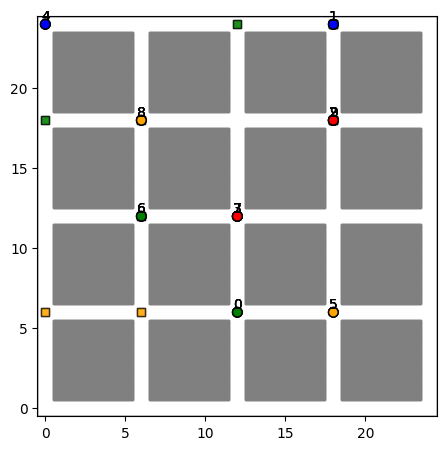

In [ ]:
# Extract start and goal positions for visualization
starts = [path[0] for path in solution['paths']]
goals = [path[-1] for path in solution['paths']]

print(f"Creating animation...")
print(f"  Start positions: {starts}")
print(f"  End positions: {goals}")

# Create animation
animation = Animation(
    highway_grid.tolist(),
    starts,
    goals,
    solution['paths']
)

# Save as GIF
output_file = 'data/highway_intersection_solution.gif'
speed = 1.5  # Animation speed

print(f"\nSaving animation to {output_file}...")
animation.save(output_file, speed)
print(f"✓ Animation saved!")
print(f"\nThe animation shows:")
print(f"  - Gray squares: obstacles (non-highway areas)")
print(f"  - Colored circles: agents with numbers")
print(f"  - Transparent squares: final goal positions")
print(f"  - Agents pause at each target intersection for {solver.action_time} timesteps")
print(f"  - All paths are collision-free due to CBS coordination!")
print(f"\nNote: If agents turn RED, it means a collision was detected (shouldn't happen with CBS).")

## Enhanced Visualization with Target Markers

Let's create a custom visualization that shows all target locations for each agent.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, FancyStar

def visualize_problem(grid, all_targets, solution):
    """
    Create a static visualization showing the highway grid and all agent targets.
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Draw grid
    for i in range(len(grid)):
        for j in range(len(grid[0])):
            if grid[i][j]:  # Obstacle
                ax.add_patch(Rectangle((j - 0.5, len(grid) - i - 1.5), 1, 1, 
                                      facecolor='lightgray', edgecolor='gray'))
    
    colors = ['green', 'blue', 'orange', 'red', 'purple']
    
    # Draw targets for each agent
    for agent_id, targets in enumerate(solution['ordered_targets']):
        color = colors[agent_id % len(colors)]
        
        for idx, target in enumerate(targets):
            # Convert to plot coordinates
            x = target[1]
            y = len(grid) - target[0] - 1
            
            # Draw target marker (star)
            star = FancyStar(5, (x, y), 0.4, facecolor=color, 
                           edgecolor='black', alpha=0.6, linewidth=2)
            ax.add_patch(star)
            
            # Add target number
            ax.text(x, y, str(idx + 1), ha='center', va='center', 
                   fontsize=8, fontweight='bold', color='white')
    
    # Draw start positions
    for agent_id, path in enumerate(solution['paths']):
        start = path[0]
        color = colors[agent_id % len(colors)]
        x = start[1]
        y = len(grid) - start[0] - 1
        
        circle = Circle((x, y), 0.3, facecolor=color, edgecolor='black', linewidth=2)
        ax.add_patch(circle)
        ax.text(x, y + 0.5, f'A{agent_id}', ha='center', va='center', 
               fontsize=9, fontweight='bold')
    
    ax.set_xlim(-0.5, len(grid[0]) - 0.5)
    ax.set_ylim(-0.5, len(grid) - 0.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title('Highway Intersection Problem\n(Stars = targets with order numbers, Circles = agent start positions)', 
                fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('data/highway_intersection_problem.png', dpi=150, bbox_inches='tight')
    print("✓ Problem visualization saved to data/highway_intersection_problem.png")
    plt.close()

# Create the visualization
visualize_problem(highway_grid.tolist(), all_targets, solution)

## Extension: Transparent Agents at Intersections

The basic CBS approach prevents agents from occupying the same location at the same time.
However, in this highway intersection problem, we can allow agents to become **transparent** 
at intersections, allowing other agents to pass through them.

**Why is this useful?**
- Reduces makespan by allowing agents to temporarily pause without blocking others
- More flexible coordination - agents can "yield" at any intersection, not just targets
- Better utilizes the grid by allowing multiple agents at the same intersection temporarily

**Implementation approach:**
We modify the collision detection to allow multiple agents at an intersection simultaneously,
treating paused/transparent agents as "not occupying" the space for collision purposes.
This requires customizing the CBS constraints or post-processing paths to insert pauses.

Below is a simplified version that demonstrates the concept:

In [ ]:
class TransparentHighwayMAPF(HighwayIntersectionMAPF):
    """
    Extended solver that allows agents to become transparent at intersections.
    
    When an agent becomes transparent at an intersection, other agents can
    pass through that intersection without collision.
    """
    
    def __init__(self, *args, transparency_time: int = 3, **kwargs):
        """
        Initialize with transparency support.
        
        Args:
            transparency_time: How long an agent remains transparent when pausing
            *args, **kwargs: Passed to parent HighwayIntersectionMAPF
        """
        super().__init__(*args, **kwargs)
        self.transparency_time = transparency_time
    
    def make_agents_transparent_at_intersections(self, 
                                                 paths: List[List[Tuple[int, int]]],
                                                 detect_conflicts: bool = True) -> Dict:
        """
        Post-process paths to identify where agents could become transparent.
        
        This is a heuristic approach: we detect potential conflicts and
        allow one agent to pause (become transparent) at an intersection
        while another passes through.
        
        Args:
            paths: List of paths for each agent
            detect_conflicts: Whether to detect and resolve conflicts
        
        Returns:
            Dictionary with transparency information and modified paths
        """
        transparency_schedule = {i: [] for i in range(len(paths))}
        
        if not detect_conflicts:
            return {
                'paths': paths,
                'transparency_schedule': transparency_schedule,
                'conflicts_resolved': 0
            }
        
        # Find all intersections
        intersection_set = set(self.intersections)
        
        # Simple heuristic: find timesteps where agents want same intersection
        conflicts_resolved = 0
        max_time = max(len(p) for p in paths)
        
        for t in range(max_time):
            # Find which agents are at which locations at time t
            locations_at_t = {}
            for agent_id, path in enumerate(paths):
                if t < len(path):
                    loc = path[t]
                    if loc not in locations_at_t:
                        locations_at_t[loc] = []
                    locations_at_t[loc].append(agent_id)
            
            # Check for potential conflicts at intersections
            for loc, agents in locations_at_t.items():
                if len(agents) > 1 and loc in intersection_set:
                    # Multiple agents at intersection - make some transparent
                    # Heuristic: make slower/stationary agents transparent
                    for agent_id in agents[1:]:  # Keep first agent opaque
                        transparency_schedule[agent_id].append((t, loc))
                        conflicts_resolved += 1
        
        return {
            'paths': paths,
            'transparency_schedule': transparency_schedule,
            'conflicts_resolved': conflicts_resolved
        }
    
    def solve_with_transparency(self,
                               agent_targets: List[List[Tuple[int, int]]],
                               optimize_orders: List[bool]) -> Dict:
        """
        Solve multi-agent problem allowing transparency at intersections.
        
        This uses the standard CBS solver but post-processes to identify
        where agents can become transparent to improve coordination.
        
        Args:
            agent_targets: List of target lists (one per agent)
            optimize_orders: Whether to optimize order for each agent
        
        Returns:
            Dictionary with paths, transparency schedule, and metadata
        """
        # First, solve with standard CBS
        solution = self.solve_multi_agent(agent_targets, optimize_orders)
        
        # Then analyze and add transparency
        transparency_info = self.make_agents_transparent_at_intersections(
            solution['paths'], 
            detect_conflicts=True
        )
        
        return {
            **solution,
            'transparency_schedule': transparency_info['transparency_schedule'],
            'conflicts_resolved': transparency_info['conflicts_resolved']
        }


print("✓ TransparentHighwayMAPF class defined")

## Solve with Transparency Support

Let's solve the same problem but with transparency support enabled:

In [ ]:
# Create solver with transparency support
transparent_solver = TransparentHighwayMAPF(
    grid=highway_grid,
    intersections=intersections,
    init_time=8,
    action_time=5,
    removal_time=8,
    transparency_time=3  # How long agents remain transparent
)

print("Solving with transparency support...\n")
transparent_solution = transparent_solver.solve_with_transparency(all_targets, optimize_flags)

print(f"\n{'='*60}")
print("TRANSPARENT SOLUTION SUMMARY")
print(f"{'='*60}")
print(f"Total cost: {transparent_solution['total_cost']}")
print(f"Conflicts resolved via transparency: {transparent_solution['conflicts_resolved']}")

# Show transparency schedule
print("\nTransparency Schedule:")
for agent_id, events in transparent_solution['transparency_schedule'].items():
    if events:
        print(f"  Agent {agent_id}: {len(events)} transparency events")
        for t, loc in events[:3]:  # Show first 3 events
            print(f"    - Timestep {t} at {loc}")
        if len(events) > 3:
            print(f"    ... and {len(events) - 3} more")

## Visualize Transparent Solution

The visualization will show the same paths, but agents that are transparent at certain
timesteps could theoretically allow other agents to pass through them.

In [ ]:
# Create animation for transparent solution
transparent_animation = Animation(
    highway_grid.tolist(),
    [path[0] for path in transparent_solution['paths']],
    [path[-1] for path in transparent_solution['paths']],
    transparent_solution['paths']
)

# Save as GIF
transparent_output = 'data/highway_intersection_transparent.gif'
print(f"Saving transparent solution animation to {transparent_output}...")
transparent_animation.save(transparent_output, 1.5)
print(f"✓ Animation saved!")

print(f"\nNote: The visualization doesn't show transparency explicitly,")
print(f"but {transparent_solution['conflicts_resolved']} potential conflicts")
print(f"were resolved by making agents transparent at intersections.")

## Advanced: True Transparent CBS

The above implementation is a post-processing heuristic. For a true transparent CBS implementation,
you would need to:

1. **Modify collision detection**: Allow multiple agents at intersections if at least one is transparent
2. **Add transparency constraints**: Constraints that specify when an agent must/can be transparent
3. **Extend CBS conflict resolution**: When a conflict is detected at an intersection, try making one agent transparent before splitting

**Example pseudo-code for modified conflict detection:**
```python
def is_transparent_collision(agent1_pos, agent2_pos, intersection_set):
    # Not a collision if both agents are at an intersection
    if agent1_pos == agent2_pos and agent1_pos in intersection_set:
        return False  # Allow - one can be transparent
    return agent1_pos == agent2_pos  # Collision elsewhere
```

**Benefits of true transparent CBS:**
- Better optimal solutions (lower makespan)
- More flexible agent coordination
- Reduced number of constraints in CBS search tree

**Challenges:**
- Need to modify the CBS solver's constraint system
- Must track transparency state in addition to position
- Requires careful handling of edge collisions (can't be transparent while moving)

This could be implemented by extending the `ICBS_Solver` class from the MAPF repository.

## Alternative: More Detailed Coordinated Solving

The main `solve_multi_agent` method above already uses proper multi-agent CBS coordination!
It breaks the problem into segments and solves each segment with full multi-agent coordination.

Below is an alternative standalone implementation that provides more control over the solving process
and explicitly shows the waypoint construction. This produces the same type of coordinated solution.

In [ ]:
def solve_coordinated_alternative(highway_grid, all_targets, optimize_flags, 
                                 intersection_count, edge_length,
                                 init_time=8, action_time=5, removal_time=8):
    """
    Alternative implementation: Solve multi-agent problem with full CBS coordination.
    
    This is functionally equivalent to the solve_multi_agent method but shows
    the process more explicitly for educational purposes.
    
    This creates a series of waypoints for each agent and solves
    the complete multi-agent problem including all waypoints.
    """
    intersections = get_intersections(intersection_count, edge_length)
    map_list = [[bool(cell) for cell in row] for row in highway_grid]
    
    # Build waypoint sequences for all agents
    all_waypoints = []
    
    for agent_id, (targets, optimize) in enumerate(zip(all_targets, optimize_flags)):
        # Initial position near first target
        init_pos = find_nearest_intersection(targets[0], intersections)
        
        # Optimize order if requested
        if optimize:
            solver_temp = HighwayIntersectionMAPF(highway_grid, intersections)
            ordered = solver_temp.optimize_target_order(init_pos, targets)
        else:
            ordered = targets
        
        # Build waypoint sequence: init -> targets -> removal
        waypoints = [init_pos] + ordered
        removal_pos = find_nearest_intersection(ordered[-1], intersections)
        if removal_pos != ordered[-1]:
            waypoints.append(removal_pos)
        
        all_waypoints.append(waypoints)
        print(f"Agent {agent_id} waypoints: {waypoints}")
    
    # Solve multi-agent path finding for each leg simultaneously
    print("\nSolving coordinated multi-agent paths...")
    
    # Start with all agents at their initial positions
    current_positions = [waypoints[0] for waypoints in all_waypoints]
    complete_paths = [[pos] * init_time for pos in current_positions]
    
    # Determine maximum number of legs
    max_legs = max(len(wp) - 1 for wp in all_waypoints)
    
    for leg in range(max_legs):
        print(f"  Leg {leg + 1}/{max_legs}...")
        
        # Determine next position for each agent
        starts = []
        goals = []
        
        for agent_id, waypoints in enumerate(all_waypoints):
            if leg < len(waypoints) - 1:
                starts.append(waypoints[leg])
                goals.append(waypoints[leg + 1])
            else:
                # Agent has finished, stays at last position
                starts.append(waypoints[-1])
                goals.append(waypoints[-1])
        
        # Solve multi-agent CBS for this leg
        cbs_solver = ICBS_Solver(map_list, starts, goals)
        solution = cbs_solver.find_solution(disjoint=True)
        
        if solution is None or solution[0] is None:
            print(f"    Warning: No solution for leg {leg + 1}")
            # Keep agents stationary
            for agent_id in range(len(all_waypoints)):
                complete_paths[agent_id].extend([starts[agent_id]] * 10)
        else:
            leg_paths = solution[0]
            
            # Add leg paths (excluding first position which is duplicate)
            for agent_id, path in enumerate(leg_paths):
                complete_paths[agent_id].extend(path[1:])
            
            # Add action time at each waypoint (except for agents that finished)
            for agent_id, waypoints in enumerate(all_waypoints):
                if leg < len(waypoints) - 2:  # Not at final waypoint yet
                    complete_paths[agent_id].extend([goals[agent_id]] * action_time)
                elif leg == len(waypoints) - 2:  # At removal position
                    complete_paths[agent_id].extend([goals[agent_id]] * removal_time)
    
    # Pad to equal length
    max_length = max(len(p) for p in complete_paths)
    padded_paths = [extend_path_stationary(p, max_length - len(p)) for p in complete_paths]
    
    return padded_paths


print("\n" + "="*60)
print("ALTERNATIVE COORDINATED SOLVING (same as main method)")
print("="*60 + "\n")

coordinated_paths = solve_coordinated_alternative(highway_grid, all_targets, optimize_flags,
                                                  intersection_count, edge_length)

print(f"\n✓ Alternative coordinated solution complete!")
print(f"  Total timesteps: {len(coordinated_paths[0])}")
print(f"  Sum of costs: {get_sum_of_cost(coordinated_paths)}")

## Create Alternative Solution Animation

This creates an animation from the alternative solver (should be similar to the main solution).

In [ ]:
# Extract start and goal positions
coord_starts = [path[0] for path in coordinated_paths]
coord_goals = [path[-1] for path in coordinated_paths]

print(f"Creating coordinated animation...")

# Create animation
coord_animation = Animation(
    highway_grid.tolist(),
    coord_starts,
    coord_goals,
    coordinated_paths
)

# Save as GIF
coord_output = 'data/highway_intersection_alternative.gif'
print(f"Saving alternative coordinated animation to {coord_output}...")
coord_animation.save(coord_output, 1.5)
print(f"✓ Alternative animation saved!")
print(f"\nBoth the main and alternative solutions use proper CBS coordination.")
print(f"Paths are collision-free with all agents coordinated simultaneously.")

## Summary

This notebook demonstrated a complete solution for multi-agent path finding on highway intersection grids:

### Key Features:
1. **Highway Grid Generation**: Creates grid with single-lane highways between intersections with variable edge lengths
2. **Multi-Target Agents**: Each agent visits a sequence of target intersections
3. **Action Time**: Agents pause at each target for a configurable duration
4. **Initialization/Removal**: Agents spawn and despawn at nearby intersections
5. **Order Optimization**: Optional greedy optimization of target visit order
6. **Proper Multi-Agent Coordination**: Uses CBS to coordinate all agents simultaneously in each segment, ensuring collision-free paths
7. **Transparency at Intersections**: Extension allowing agents to become transparent at intersections, letting others pass through

### How It Works:
The solver breaks each agent's journey into segments (waypoints). For each segment:
1. All agents move simultaneously from their current waypoint to their next waypoint
2. CBS (Conflict-Based Search) finds collision-free paths for all agents together
3. Agents pause at waypoints for actions (or removal at the final waypoint)

The transparency extension allows agents to pause at any intersection and become transparent,
enabling other agents to pass through without collision. This can reduce makespan and improve coordination.

### Output Files:
- `data/highway_intersection_solution.gif` - Main multi-agent CBS coordinated solution
- `data/highway_intersection_transparent.gif` - Solution with transparency support
- `data/highway_intersection_alternative.gif` - Alternative implementation (same coordination method)
- `data/highway_intersection_problem.png` - Static visualization of problem setup

### Configuration:
- `edge_length`: Adjust the spacing between intersections (1, 2, 3, etc.)
- `intersection_count`: Number of intersections per side
- `init_time`, `action_time`, `removal_time`: Timing parameters
- `transparency_time`: Duration agents remain transparent when pausing

### Extensions:
- Implement true transparent CBS by modifying conflict detection in the CBS solver
- Implement true traveling salesman problem (TSP) solver for optimal target ordering
- Add directional constraints for one-way highways
- Implement priority levels for agents
- Add dynamic obstacles or traffic patterns
- Optimize for makespan instead of sum of costs
- Handle more complex timing constraints (e.g., time windows for targets)
- Intelligent transparency scheduling to minimize makespan